In [ ]:
# =====================
# Cell 1: Imports and Configuration
# =====================
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import expit as sigmoid
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT_DIR = Path(
    "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train"
)
AF3_PATH = ROOT_DIR / "data/source-nopackinput/af3_rosetta.csv"
OUTPUT_DIR = ROOT_DIR / "data/train_result/nopackinput_af3_only"

FEATURE_COLUMNS = [
    "dG_separated/dSASAx100",
    "energy_per_intres",
    "dSASA_int_per_res",
]
SOURCE_COLUMN = "source"
TARGET_COLUMN = "target"
LABEL_COLUMN = "label"

N_SPLITS = 5
N_REPEATS = 50
N_FEATURES = len(FEATURE_COLUMNS)
BASE_SEED = 20260415
C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
EPS = 1e-15

SAFE_FEATURE_NAMES = [f.replace("/", "_") for f in FEATURE_COLUMNS]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "eda").mkdir(parents=True, exist_ok=True)


Removed 1 exact duplicate rows.
Total AF3 rows (after cleaning): 3209
Label counts:
label
0    1837
1    1372
Unique targets: 107

=== Feature Statistics ===
       dG_separated/dSASAx100  energy_per_intres
count               3209.0000          3209.0000
mean                  -1.8803            -1.8390
std                    1.1593             0.8801
min                   -4.5850            -3.9990
25%                   -2.7420            -2.3940
50%                   -2.0430            -1.9230
75%                   -1.1930            -1.3120
max                    5.9880             3.0010


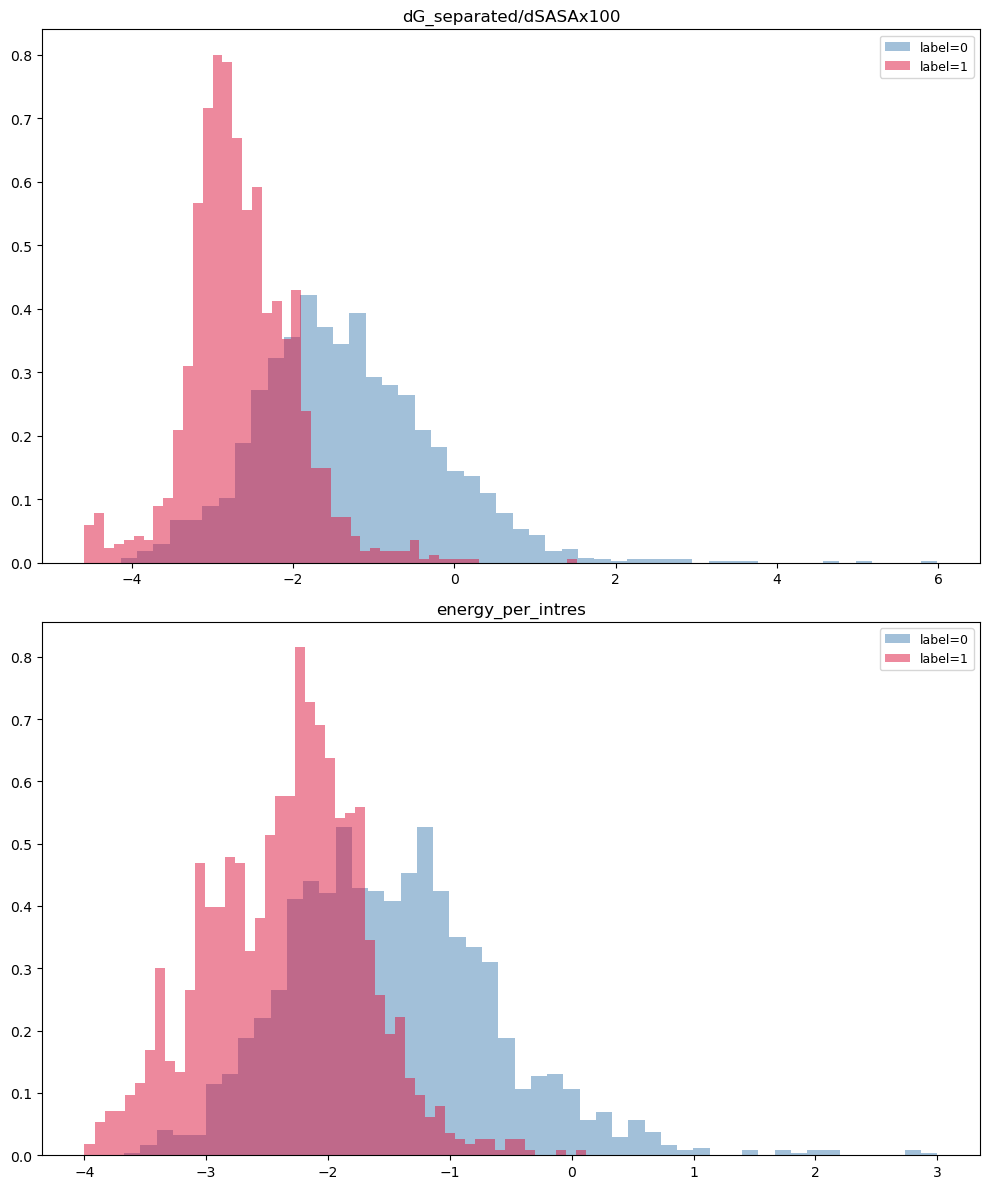

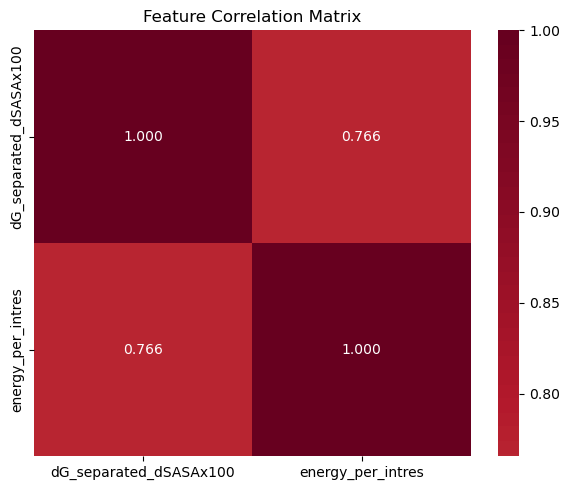

EDA figures saved to: /home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/data/train_result/nopackinput_af3_only/eda


In [9]:
# =====================
# Cell 2: Data Loading, Cleaning, and Feature Distribution Check
# =====================

# --- 2a. Load and clean ---

model_df = pd.read_csv(AF3_PATH)
model_df[SOURCE_COLUMN] = "AF3"
model_df[TARGET_COLUMN] = model_df[TARGET_COLUMN].astype(str)

for col in FEATURE_COLUMNS:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
model_df[LABEL_COLUMN] = pd.to_numeric(model_df[LABEL_COLUMN], errors="coerce")

initial_len = len(model_df)
model_df = model_df.dropna(subset=[TARGET_COLUMN, LABEL_COLUMN] + FEATURE_COLUMNS)
if (dropped := initial_len - len(model_df)):
    print(f"Dropped {dropped} rows with missing values.")

model_df[LABEL_COLUMN] = model_df[LABEL_COLUMN].astype(int)

dup_mask = model_df.duplicated(subset=[TARGET_COLUMN, LABEL_COLUMN] + FEATURE_COLUMNS)
if (dup_count := int(dup_mask.sum())):
    print(f"Removed {dup_count} exact duplicate rows.")
    model_df[dup_mask].to_csv(OUTPUT_DIR / "duplicate_rows.csv", index=False)
    model_df = model_df.loc[~dup_mask]

model_df = model_df.reset_index(drop=True)

print(f"Total AF3 rows (after cleaning): {len(model_df)}")
print(f"Label counts:\n{model_df[LABEL_COLUMN].value_counts().to_string()}")
print(f"Unique targets: {model_df[TARGET_COLUMN].nunique()}")

# --- 2b. Feature distribution ---

print(f"\n=== Feature Statistics ===\n{model_df[FEATURE_COLUMNS].describe().round(4).to_string()}")

# Histograms: by label
fig, axes = plt.subplots(N_FEATURES, 1, figsize=(10, 12))
for i, feat in enumerate(FEATURE_COLUMNS):
    for lbl, color in [(0, "steelblue"), (1, "crimson")]:
        axes[i].hist(model_df.loc[model_df[LABEL_COLUMN] == lbl, feat],
                     bins=50, alpha=0.5, density=True,
                     label=f"label={lbl}", color=color)
    axes[i].set_title(f"{feat}")
    axes[i].legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda/feature_histograms.png", dpi=300)
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
corr = model_df[FEATURE_COLUMNS].corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax,
            xticklabels=SAFE_FEATURE_NAMES, yticklabels=SAFE_FEATURE_NAMES)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda/correlation_heatmap.png", dpi=300)
plt.show()
print(f"EDA figures saved to: {OUTPUT_DIR / 'eda'}")

X_all = model_df[FEATURE_COLUMNS].copy()
y_all = model_df[LABEL_COLUMN].astype(int).to_numpy()


In [10]:
# =====================
# Cell 3: Utility Functions
# =====================


# --- F1-based threshold ---

def compute_f1_threshold(y_true: np.ndarray, y_prob: np.ndarray):
    """Find the probability threshold that maximizes F1 on the PR curve."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, float(precision[-1]), float(recall[-1]), 0.0
    prec = precision[1:]
    rec = recall[1:]
    f1_scores = 2 * prec * rec / np.maximum(prec + rec, EPS)
    best = int(np.argmax(f1_scores))
    return float(thresholds[best]), float(prec[best]), float(rec[best]), float(f1_scores[best])


# --- Evaluation ---

def evaluate_probability_predictions(y_true: np.ndarray, y_prob: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(np.unique(y_true)) < 2:
        raise ValueError("Both classes required for ROC-AUC and PR-AUC.")

    roc_auc = float(roc_auc_score(y_true, y_prob))
    pr_auc = float(average_precision_score(y_true, y_prob))

    best_threshold, best_precision, best_recall, best_f1 = compute_f1_threshold(y_true, y_prob)

    y_pred = (y_prob >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "best_threshold": best_threshold,
        "best_precision": best_precision,
        "best_recall": best_recall,
        "best_f1": best_f1,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


# --- Sample weights ---

def compute_sample_weights(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=int)
    class_counts = pd.Series(y).value_counts().to_dict()
    n_samples = float(len(y))
    n_classes = float(len(class_counts))
    return np.asarray([n_samples / (n_classes * class_counts[label]) for label in y])


# --- Model builder (sklearn) ---

def build_sklearn_model(random_state: int, C: float) -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000, solver="lbfgs", penalty="l2",
            C=C, random_state=random_state,
        )),
    ])


# --- Custom L-BFGS logistic regression with loss tracking ---

def _logistic_loss_and_grad(params: np.ndarray, X: np.ndarray, y: np.ndarray, C: float):
    n_features = X.shape[1]
    w = params[:n_features]
    b = params[n_features]
    z = np.clip(X @ w + b, -500, 500)
    p = sigmoid(z)
    p = np.clip(p, EPS, 1 - EPS)
    n = len(y)
    loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)) + 0.5 / C * np.sum(w ** 2)
    error = p - y
    dw = X.T @ error / n + w / C
    db = np.mean(error)
    return loss, np.concatenate([dw, [db]])


def fit_logistic_lbfgs(X, y, C=1.0, max_iter=1000, X_val=None, y_val=None):
    """Fit logistic regression via L-BFGS-B, tracking train/val loss per iteration."""
    X_np = np.asarray(X, dtype=float)
    y_np = np.asarray(y, dtype=float)
    n_features = X_np.shape[1]

    train_losses = []
    val_losses = []
    has_val = X_val is not None and y_val is not None

    def callback(params):
        tr_loss, _ = _logistic_loss_and_grad(params, X_np, y_np, C)
        train_losses.append(tr_loss)
        if has_val:
            vl_loss, _ = _logistic_loss_and_grad(params, X_val, y_val, C)
            val_losses.append(vl_loss)

    result = minimize(
        fun=lambda p: _logistic_loss_and_grad(p, X_np, y_np, C),
        x0=np.zeros(n_features + 1),
        jac=True,
        method="L-BFGS-B",
        options={"maxiter": max_iter, "gtol": 1e-5},
        callback=callback,
    )

    w = result.x[:n_features]
    b = result.x[n_features]
    return w, b, train_losses, val_losses


# --- Parameter extraction ---

def extract_raw_parameters(model: Pipeline):
    scaler = model.named_steps["scaler"]
    clf = model.named_steps["clf"]
    std_coef = np.asarray(clf.coef_[0])
    std_intercept = float(clf.intercept_[0])
    scale = np.asarray(scaler.scale_)
    mean = np.asarray(scaler.mean_)
    raw_coef = std_coef / scale
    raw_intercept = std_intercept - float(np.sum((std_coef * mean) / scale))
    return raw_coef, raw_intercept, std_coef, std_intercept


# --- Formula formatting ---

def format_glm_formula(feature_names, coefficients, bias):
    terms = [f"({bias:.6f})"]
    for name, coef in zip(feature_names, coefficients):
        terms.append(f"({coef:.6f}) * {name}")
    return "logit = " + " + ".join(terms) + "\nprobability = 1 / (1 + exp(-logit))"


# --- Fold label summary ---

def summarize_fold_labels(df: pd.DataFrame, fold_assignment: np.ndarray) -> pd.DataFrame:
    rows = []
    for fold_idx in range(N_SPLITS):
        fold_df = df.loc[fold_assignment == fold_idx]
        pos = int((fold_df[LABEL_COLUMN] == 1).sum())
        neg = int((fold_df[LABEL_COLUMN] == 0).sum())
        rows.append({
            "fold": fold_idx, "n_samples": len(fold_df),
            "n_targets": int(fold_df[TARGET_COLUMN].nunique()),
            "n_pos": pos, "n_neg": neg,
            "label_gap": abs(pos - neg),
            "has_both_labels": pos > 0 and neg > 0,
        })
    return pd.DataFrame(rows)


# --- Single-feature CV evaluator ---

def evaluate_single_feature_oof(X, y, feature_idx, C, random_state):
    """Run 5-fold stratified CV for a single feature, return OOF probs + metrics."""
    feature_name = FEATURE_COLUMNS[feature_idx]
    X_single = X[[feature_name]]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=random_state)
    oof = np.full(len(y), np.nan)
    for train_idx, test_idx in skf.split(X_single, y):
        X_tr, X_te = X_single.iloc[train_idx], X_single.iloc[test_idx]
        y_tr = y[train_idx]
        w = compute_sample_weights(y_tr)
        m = LogisticRegression(C=C, max_iter=2000, solver="lbfgs", penalty="l2", random_state=random_state)
        m.fit(X_tr, y_tr, sample_weight=w)
        oof[test_idx] = m.predict_proba(X_te)[:, 1]
    return oof, evaluate_probability_predictions(y, oof)


Grid search for C over [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

Best C = 1000.0  (mean ROC-AUC = 0.8646)
       C  mean_roc_auc  std_roc_auc
   0.001      0.858457     0.005165
   0.010      0.862815     0.003550
   0.100      0.864561     0.002359
   1.000      0.864607     0.002021
  10.000      0.864636     0.002016
 100.000      0.864640     0.002005
1000.000      0.864642     0.002005


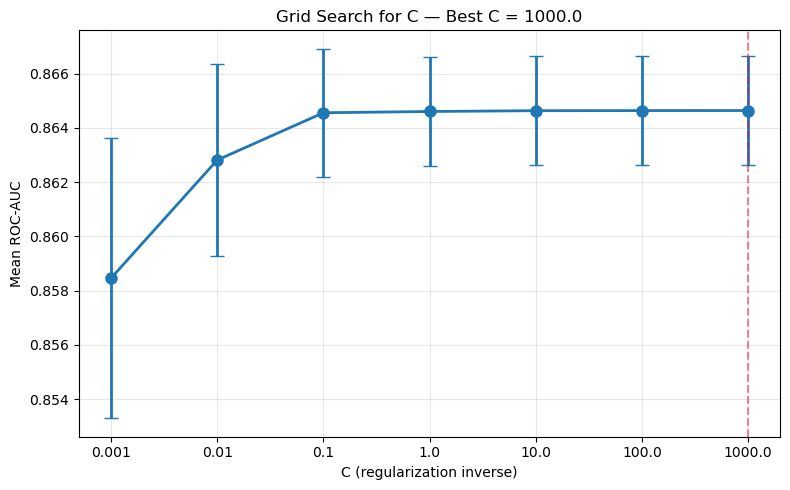

In [11]:
# =====================
# Cell 4: Grid Search for Regularization Strength C
# =====================

print("Grid search for C over", C_GRID)
grid_results = []
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=BASE_SEED)

for C_val in C_GRID:
    fold_aucs = []
    for train_idx, test_idx in skf.split(X_all, y_all):
        X_tr, X_te = X_all.iloc[train_idx], X_all.iloc[test_idx]
        y_tr, y_te = y_all[train_idx], y_all[test_idx]
        w = compute_sample_weights(y_tr)
        model = build_sklearn_model(random_state=BASE_SEED, C=C_val)
        model.fit(X_tr, y_tr, clf__sample_weight=w)
        prob = model.predict_proba(X_te)[:, 1]
        if len(np.unique(y_te)) >= 2:
            fold_aucs.append(roc_auc_score(y_te, prob))
    grid_results.append({
        "C": C_val,
        "mean_roc_auc": np.mean(fold_aucs),
        "std_roc_auc": np.std(fold_aucs, ddof=1),
    })

grid_df = pd.DataFrame(grid_results)
best_C = grid_df.loc[grid_df["mean_roc_auc"].idxmax(), "C"]
print(f"\nBest C = {best_C}  (mean ROC-AUC = {grid_df['mean_roc_auc'].max():.4f})")
print(grid_df.to_string(index=False))

grid_df.to_csv(OUTPUT_DIR / "c_grid_search.csv", index=False)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(range(len(C_GRID)), grid_df["mean_roc_auc"], yerr=grid_df["std_roc_auc"],
            fmt="o-", capsize=5, linewidth=2, markersize=8)
ax.set_xticks(range(len(C_GRID)))
ax.set_xticklabels([str(c) for c in C_GRID])
ax.set_xlabel("C (regularization inverse)")
ax.set_ylabel("Mean ROC-AUC")
ax.set_title(f"Grid Search for C — Best C = {best_C}")
ax.axvline(x=grid_df["mean_roc_auc"].idxmax(), color="crimson", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "c_grid_search.png", dpi=300)
plt.show()


In [12]:
# =====================
# Cell 5: Repeated 5-Fold CV with Loss Tracking
# =====================

print(f"Running {N_REPEATS} repeated {N_SPLITS}-fold CV with best_C = {best_C} ...\n")

repeat_summary_rows = []
repeat_parameter_rows = []
repeat_oof_matrix = np.empty((N_REPEATS, len(model_df)), dtype=float)
loss_records = []

for repeat_idx in range(N_REPEATS):
    repeat_seed = BASE_SEED + repeat_idx

    # StratifiedGroupKFold: stratify by label, group by target
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=repeat_seed)
    strata = model_df[LABEL_COLUMN].astype(int).astype(str)
    groups = model_df[TARGET_COLUMN].astype(str).to_numpy()

    fold_assignment = np.full(len(model_df), -1, dtype=int)
    for fold_idx, (_, test_idx) in enumerate(sgkf.split(np.zeros(len(model_df)), strata, groups)):
        fold_assignment[test_idx] = fold_idx
    if (fold_assignment < 0).any():
        raise RuntimeError("Fold assignment incomplete.")

    fold_summary = summarize_fold_labels(model_df, fold_assignment)

    repeat_oof = np.full(len(model_df), np.nan, dtype=float)
    fold_raw_coefs, fold_std_coefs = [], []
    fold_raw_intercepts, fold_std_intercepts = [], []

    for fold_idx in range(N_SPLITS):
        test_mask = fold_assignment == fold_idx
        train_mask = ~test_mask

        X_train_raw = X_all.loc[train_mask].to_numpy(dtype=float)
        y_train = y_all[train_mask]
        X_test_raw = X_all.loc[test_mask].to_numpy(dtype=float)
        y_test = y_all[test_mask]

        # Standardize manually for the custom L-BFGS fit
        tr_mean = X_train_raw.mean(axis=0)
        tr_std = X_train_raw.std(axis=0, ddof=0)
        tr_std = np.where(tr_std == 0, 1.0, tr_std)
        X_train_scaled = (X_train_raw - tr_mean) / tr_std
        X_test_scaled = (X_test_raw - tr_mean) / tr_std

        w_scaled, b_scaled, train_losses, val_losses = fit_logistic_lbfgs(
            X_train_scaled, y_train, C=best_C, max_iter=1000,
            X_val=X_test_scaled, y_val=y_test,
        )

        # Record loss history
        for it, (tr_loss, vl_loss) in enumerate(zip(train_losses, val_losses)):
            loss_records.append({
                "repeat": repeat_idx + 1, "fold": fold_idx,
                "iteration": it, "train_loss": tr_loss, "val_loss": vl_loss,
            })

        # Convert to raw-space coefficients
        w_raw = w_scaled / tr_std
        b_raw = b_scaled - float(np.sum(w_scaled * tr_mean / tr_std))

        # OOF predictions (raw space)
        fold_prob = sigmoid(np.clip(X_test_raw @ w_raw + b_raw, -500, 500))
        repeat_oof[test_mask] = fold_prob

        fold_raw_coefs.append(w_raw)
        fold_std_coefs.append(w_scaled)
        fold_raw_intercepts.append(b_raw)
        fold_std_intercepts.append(b_scaled)

    repeat_oof_matrix[repeat_idx] = repeat_oof

    # Repeat-level evaluation
    repeat_eval = evaluate_probability_predictions(y_all, repeat_oof)
    split_ok = bool(fold_summary["has_both_labels"].all())

    repeat_summary_rows.append({
        "repeat": repeat_idx + 1, "seed": repeat_seed,
        "split_ok": split_ok,
        "roc_auc": repeat_eval["roc_auc"],
        "pr_auc": repeat_eval["pr_auc"],
        "best_threshold": repeat_eval["best_threshold"],
        "best_f1": repeat_eval["best_f1"],
        "accuracy": repeat_eval["accuracy"],
        "balanced_accuracy": repeat_eval["balanced_accuracy"],
        "precision": repeat_eval["precision"],
        "recall": repeat_eval["recall"],
        "f1": repeat_eval["f1"],
        "tn": repeat_eval["tn"], "fp": repeat_eval["fp"],
        "fn": repeat_eval["fn"], "tp": repeat_eval["tp"],
    })

    repeat_parameter_rows.append({
        "repeat": repeat_idx + 1,
        "raw_bias_mean": float(np.mean(fold_raw_intercepts)),
        "std_bias_mean": float(np.mean(fold_std_intercepts)),
        **{f"raw_coef_mean_{sn}": float(np.mean(vals))
           for sn, vals in zip(SAFE_FEATURE_NAMES, np.stack(fold_raw_coefs, axis=0).T)},
        **{f"std_coef_mean_{sn}": float(np.mean(vals))
           for sn, vals in zip(SAFE_FEATURE_NAMES, np.stack(fold_std_coefs, axis=0).T)},
    })

    if (repeat_idx + 1) % 10 == 0 or repeat_idx == 0:
        print(f"Repeat {repeat_idx + 1}/{N_REPEATS}: "
              f"ROC-AUC={repeat_eval['roc_auc']:.4f}, "
              f"PR-AUC={repeat_eval['pr_auc']:.4f}, "
              f"threshold={repeat_eval['best_threshold']:.4f}, "
              f"split_ok={split_ok}")

repeat_summary_df = pd.DataFrame(repeat_summary_rows)
repeat_parameter_df = pd.DataFrame(repeat_parameter_rows)
loss_df = pd.DataFrame(loss_records)

print(f"\nCompleted {len(repeat_summary_df)} repeats. "
      f"Total loss records: {len(loss_df)}")
loss_df.to_csv(OUTPUT_DIR / "loss_history.csv", index=False)


Running 50 repeated 5-fold CV with best_C = 1000.0 ...

Repeat 1/50: ROC-AUC=0.8616, PR-AUC=0.7842, threshold=0.3628, split_ok=True
Repeat 10/50: ROC-AUC=0.8626, PR-AUC=0.7860, threshold=0.3489, split_ok=True
Repeat 20/50: ROC-AUC=0.8591, PR-AUC=0.7850, threshold=0.3495, split_ok=True
Repeat 30/50: ROC-AUC=0.8480, PR-AUC=0.7676, threshold=0.3392, split_ok=True
Repeat 40/50: ROC-AUC=0.8549, PR-AUC=0.7737, threshold=0.3123, split_ok=True
Repeat 50/50: ROC-AUC=0.8583, PR-AUC=0.7781, threshold=0.3334, split_ok=True

Completed 50 repeats. Total loss records: 2232


Repeated CV summary (mean ± std across 50 repeats):
      roc_auc  pr_auc  best_threshold  best_f1
mean   0.8570  0.7768          0.3493   0.7624
std    0.0033  0.0054          0.0221   0.0038

All splits valid: True

Aggregate mean-OOF metrics:
  roc_auc: 0.857737
  pr_auc: 0.777453
  best_threshold: 0.341714
  best_precision: 0.667031
  best_recall: 0.890671
  best_f1: 0.762797
  accuracy: 0.762854
  balanced_accuracy: 0.779032
  precision: 0.666667
  recall: 0.890671
  f1: 0.762559


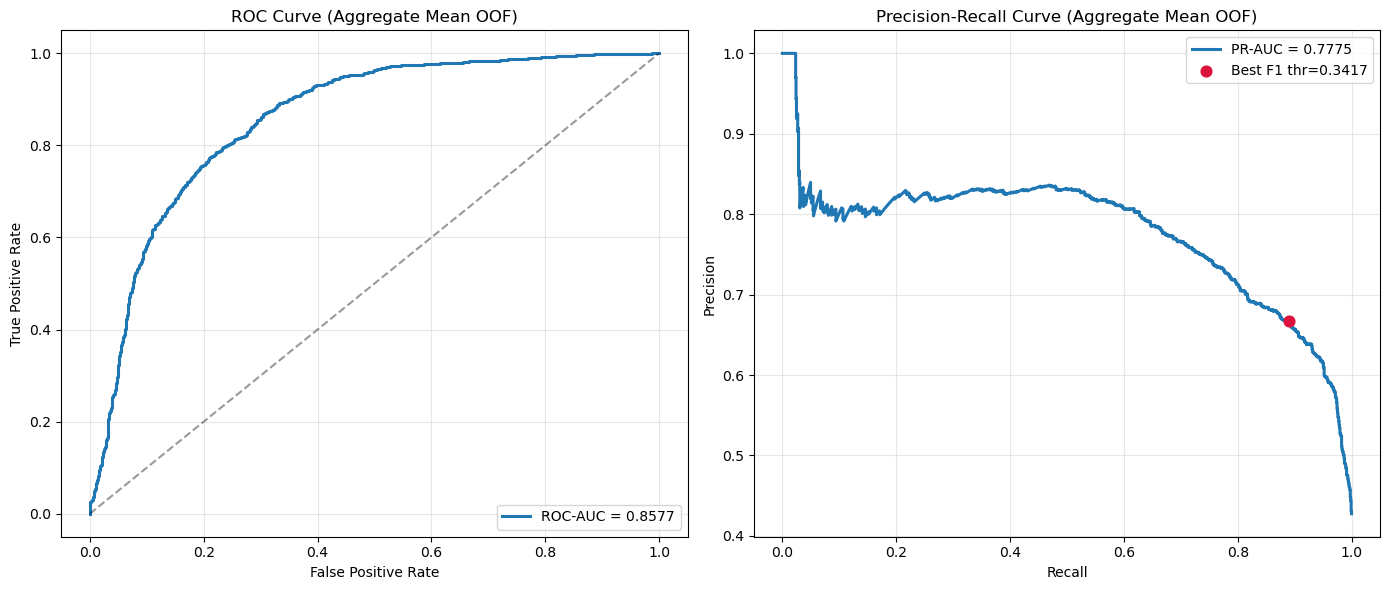

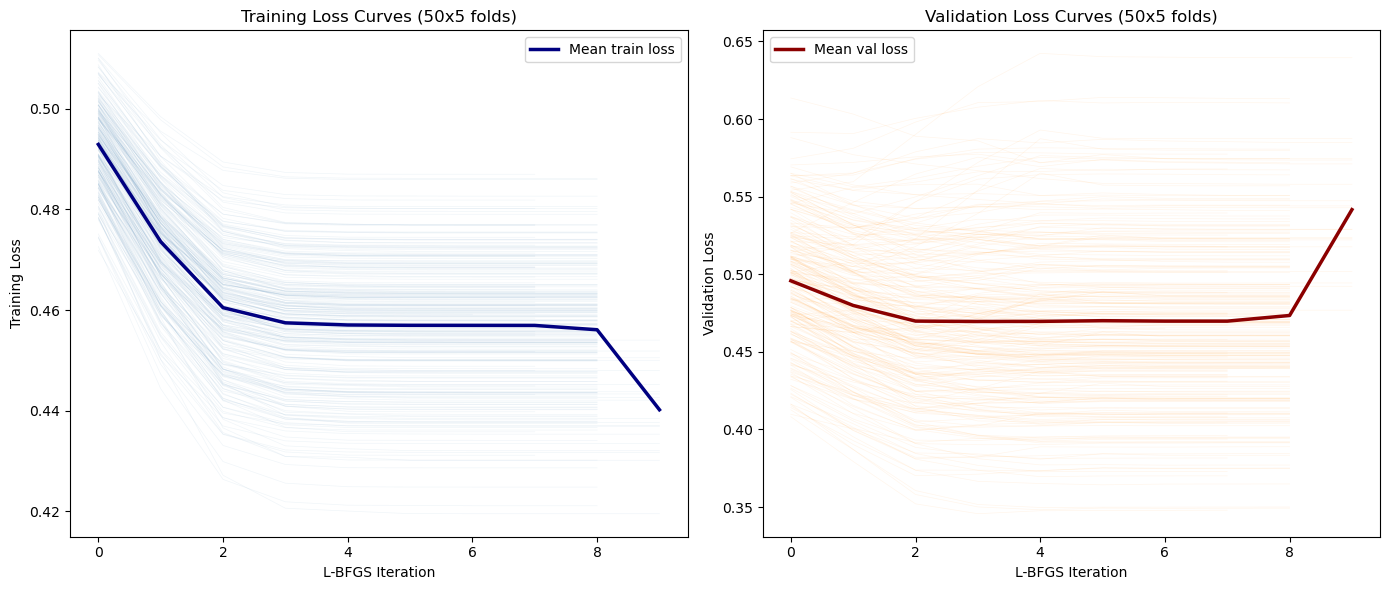


Figures saved to: /home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/data/train_result/nopackinput_af3_only


In [13]:
# =====================
# Cell 6: Aggregate Evaluation and Loss Curves
# =====================

mean_oof_prob = repeat_oof_matrix.mean(axis=0)
std_oof_prob = repeat_oof_matrix.std(axis=0, ddof=1)

aggregate_eval = evaluate_probability_predictions(y_all, mean_oof_prob)

# Save CSVs
prediction_summary_df = model_df[[SOURCE_COLUMN, TARGET_COLUMN, LABEL_COLUMN]].copy()
prediction_summary_df["mean_oof_prob"] = mean_oof_prob
prediction_summary_df["std_oof_prob"] = std_oof_prob
prediction_summary_df["mean_oof_pred"] = (mean_oof_prob >= aggregate_eval["best_threshold"]).astype(int)

repeat_summary_df.to_csv(OUTPUT_DIR / "repeat_cv_summary.csv", index=False)
prediction_summary_df.to_csv(OUTPUT_DIR / "repeat_oof_predictions.csv", index=False)
repeat_parameter_df.to_csv(OUTPUT_DIR / "repeat_parameter_summary.csv", index=False)
pd.DataFrame([aggregate_eval]).to_csv(OUTPUT_DIR / "aggregate_oof_summary.csv", index=False)

# --- QC Summary ---
print("Repeated CV summary (mean ± std across 50 repeats):")
print(repeat_summary_df[["roc_auc", "pr_auc", "best_threshold", "best_f1"]].agg(["mean", "std"]).round(4))
print(f"\nAll splits valid: {repeat_summary_df['split_ok'].all()}")
print(f"\nAggregate mean-OOF metrics:")
for k, v in aggregate_eval.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.6f}")

# --- Plot 1: Combined ROC + PR curves from aggregate OOF ---
fpr, tpr, _ = roc_curve(y_all, mean_oof_prob)
precision, recall, _ = precision_recall_curve(y_all, mean_oof_prob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(fpr, tpr, linewidth=2.2, label=f"ROC-AUC = {aggregate_eval['roc_auc']:.4f}")
ax1.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve (Aggregate Mean OOF)")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

ax2.plot(recall, precision, linewidth=2.2, label=f"PR-AUC = {aggregate_eval['pr_auc']:.4f}")
ax2.scatter([aggregate_eval["best_recall"]], [aggregate_eval["best_precision"]],
            color="crimson", s=60, zorder=3,
            label=f"Best F1 thr={aggregate_eval['best_threshold']:.4f}")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve (Aggregate Mean OOF)")
ax2.legend(loc="best")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aggregate_roc_pr_curves.png", dpi=300)
plt.show()

# --- Plot 2: Combined Loss Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for (rep, fold), grp in loss_df.groupby(["repeat", "fold"]):
    ax1.plot(grp["iteration"], grp["train_loss"], alpha=0.08, linewidth=0.5, color="steelblue")
    ax2.plot(grp["iteration"], grp["val_loss"], alpha=0.08, linewidth=0.5, color="darkorange")

mean_train = loss_df.groupby("iteration")["train_loss"].mean()
mean_val = loss_df.groupby("iteration")["val_loss"].mean()
ax1.plot(mean_train.index, mean_train.values, color="navy", linewidth=2.5, label="Mean train loss")
ax2.plot(mean_val.index, mean_val.values, color="darkred", linewidth=2.5, label="Mean val loss")

ax1.set_xlabel("L-BFGS Iteration")
ax1.set_ylabel("Training Loss")
ax1.set_title(f"Training Loss Curves ({N_REPEATS}x{N_SPLITS} folds)")
ax1.legend()

ax2.set_xlabel("L-BFGS Iteration")
ax2.set_ylabel("Validation Loss")
ax2.set_title(f"Validation Loss Curves ({N_REPEATS}x{N_SPLITS} folds)")
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curves.png", dpi=300)
plt.show()

print(f"\nFigures saved to: {OUTPUT_DIR}")


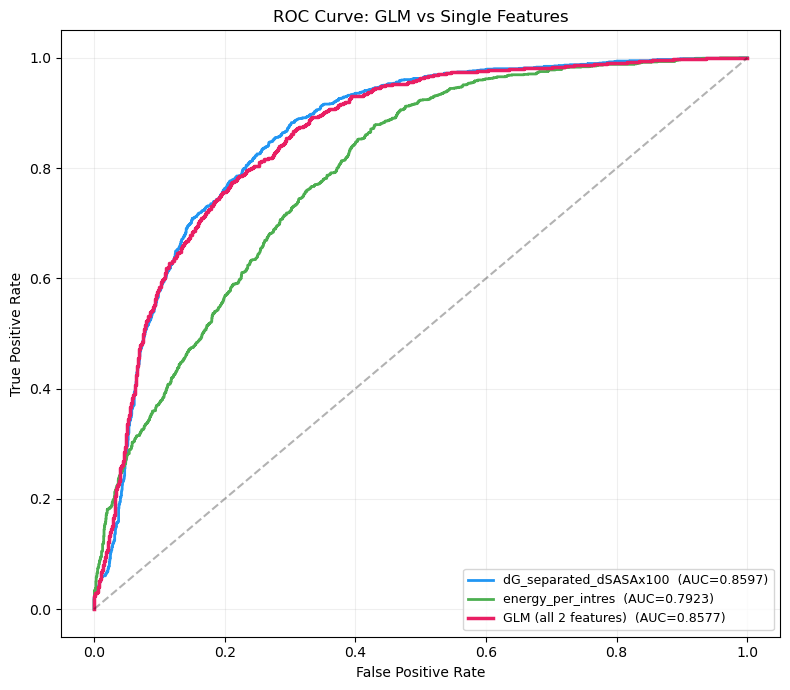

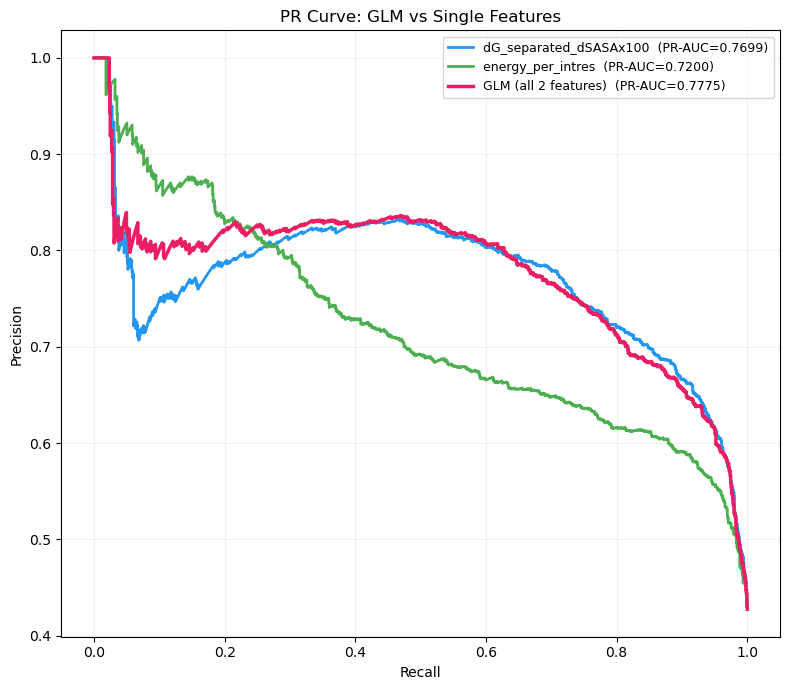


Model Comparison:
                 Model  ROC-AUC  PR-AUC  Best F1  Accuracy  Balanced Acc
dG_separated_dSASAx100   0.8597  0.7699   0.7718    0.7766        0.7900
     energy_per_intres   0.7923  0.7200   0.7160    0.7018        0.7241
  GLM (all 2 features)   0.8577  0.7775   0.7628    0.7629        0.7790


In [14]:
# =====================
# Cell 7: GLM vs Single-Feature Comparison
# =====================

colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0", "#607D8B"]

# Train single-feature models via 5-fold CV
single_results = {}
for i, feat in enumerate(FEATURE_COLUMNS):
    oof, metrics = evaluate_single_feature_oof(X_all, y_all, i, C=best_C, random_state=BASE_SEED)
    single_results[feat] = {"oof": oof, **metrics}

# Full GLM uses mean OOF from repeated CV
glm_oof = mean_oof_prob

# --- ROC Comparison ---
fig, ax = plt.subplots(figsize=(8, 7))
for i, feat in enumerate(FEATURE_COLUMNS):
    fpr, tpr, _ = roc_curve(y_all, single_results[feat]["oof"])
    ax.plot(fpr, tpr, linewidth=2, color=colors[i],
            label=f"{SAFE_FEATURE_NAMES[i]}  (AUC={single_results[feat]['roc_auc']:.4f})")

fpr_glm, tpr_glm, _ = roc_curve(y_all, glm_oof)
ax.plot(fpr_glm, tpr_glm, linewidth=2.5, color=colors[3],
        label=f"GLM (all {N_FEATURES} features)  (AUC={aggregate_eval['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: GLM vs Single Features")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "glm_vs_single_roc.png", dpi=300)
plt.show()

# --- PR Comparison ---
fig, ax = plt.subplots(figsize=(8, 7))
for i, feat in enumerate(FEATURE_COLUMNS):
    prec, rec, _ = precision_recall_curve(y_all, single_results[feat]["oof"])
    ax.plot(rec, prec, linewidth=2, color=colors[i],
            label=f"{SAFE_FEATURE_NAMES[i]}  (PR-AUC={single_results[feat]['pr_auc']:.4f})")

prec_glm, rec_glm, _ = precision_recall_curve(y_all, glm_oof)
ax.plot(rec_glm, prec_glm, linewidth=2.5, color=colors[3],
        label=f"GLM (all {N_FEATURES} features)  (PR-AUC={aggregate_eval['pr_auc']:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PR Curve: GLM vs Single Features")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "glm_vs_single_pr.png", dpi=300)
plt.show()

# --- Comparison table ---
comparison_rows = []
for i, feat in enumerate(FEATURE_COLUMNS):
    r = single_results[feat]
    comparison_rows.append({
        "Model": SAFE_FEATURE_NAMES[i],
        "ROC-AUC": r["roc_auc"],
        "PR-AUC": r["pr_auc"],
        "Best F1": r["best_f1"],
        "Accuracy": r["accuracy"],
        "Balanced Acc": r["balanced_accuracy"],
    })
comparison_rows.append({
    "Model": f"GLM (all {N_FEATURES} features)",
    "ROC-AUC": aggregate_eval["roc_auc"],
    "PR-AUC": aggregate_eval["pr_auc"],
    "Best F1": aggregate_eval["best_f1"],
    "Accuracy": aggregate_eval["accuracy"],
    "Balanced Acc": aggregate_eval["balanced_accuracy"],
})

comparison_df = pd.DataFrame(comparison_rows)
print("\nModel Comparison:")
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


In [15]:
# =====================
# Cell 8: Final Model Training and Formula Export
# =====================

# Train final model on all data
final_model = build_sklearn_model(random_state=BASE_SEED, C=best_C)
final_model.fit(X_all, y_all, clf__sample_weight=compute_sample_weights(y_all))

raw_coef, raw_bias, std_coef, std_bias = extract_raw_parameters(final_model)

# Parameter report
final_param_df = pd.DataFrame({
    "term": ["bias"] + FEATURE_COLUMNS,
    "raw_coefficient": [raw_bias] + list(raw_coef),
    "standardized_coefficient": [std_bias] + list(std_coef),
})

repeat_param_stats_df = (
    repeat_parameter_df.drop(columns=["repeat"])
    .agg(["mean", "std"]).T
    .reset_index().rename(columns={"index": "term"})
)

# Build formula
formula_text = format_glm_formula(FEATURE_COLUMNS, raw_coef, raw_bias)
threshold_text = (
    f"Best threshold from repeated CV mean OOF PR curve: {aggregate_eval['best_threshold']:.6f}\n"
    f"Best F1: {aggregate_eval['best_f1']:.6f}\n"
    f"Precision: {aggregate_eval['best_precision']:.6f}\n"
    f"Recall: {aggregate_eval['best_recall']:.6f}\n"
    f"ROC-AUC: {aggregate_eval['roc_auc']:.6f}\n"
    f"PR-AUC: {aggregate_eval['pr_auc']:.6f}\n"
    f"C (regularization): {best_C}"
)

report_text = "\n".join([
    "Final GLM Formula:",
    formula_text,
    "",
    "Threshold & Performance:",
    threshold_text,
    "",
    "Final Parameters:",
    final_param_df.to_string(index=False),
    "",
    "Parameter Stability (mean ± std across 50 repeats):",
    repeat_param_stats_df.to_string(index=False),
])

(OUTPUT_DIR / "final_glm_report.txt").write_text(report_text, encoding="utf-8")
final_param_df.to_csv(OUTPUT_DIR / "final_glm_parameters.csv", index=False)
repeat_param_stats_df.to_csv(OUTPUT_DIR / "repeat_parameter_stats.csv", index=False)

print(report_text)
print(f"\nReport saved to: {OUTPUT_DIR / 'final_glm_report.txt'}")


Final GLM Formula:
logit = (-4.365444) + (-1.554760) * dG_separated/dSASAx100 + (-0.565471) * energy_per_intres
probability = 1 / (1 + exp(-logit))

Threshold & Performance:
Best threshold from repeated CV mean OOF PR curve: 0.341714
Best F1: 0.762797
Precision: 0.667031
Recall: 0.890671
ROC-AUC: 0.857737
PR-AUC: 0.777453
C (regularization): 1000.0

Final Parameters:
                  term  raw_coefficient  standardized_coefficient
                  bias        -4.365444                 -0.402126
dG_separated/dSASAx100        -1.554760                 -1.802213
     energy_per_intres        -0.565471                 -0.497569

Parameter Stability (mean ± std across 50 repeats):
                                term      mean      std
                       raw_bias_mean -4.602924 0.011033
                       std_bias_mean -0.679754 0.002343
raw_coef_mean_dG_separated_dSASAx100 -1.501630 0.005734
     raw_coef_mean_energy_per_intres -0.598225 0.006492
std_coef_mean_dG_separated_dSASAx